In [98]:
try:
    import pypdf
except ImportError:
    !pip install -q pypdf

import pypdf

pdf_path = '/content/ML team tasks ramp up  week 1 ASMICORE AGTP.pdf'
reader = pypdf.PdfReader(pdf_path)
full_text = ""
for page in reader.pages:
    full_text += page.extract_text() + "\n"

print("--- PDF Content Excerpt ---")
print(full_text[:2000] + "...") # Printing the first 2000 characters to check requirements

--- PDF Content Excerpt ---
  
` 
ML Team 
 
 
  1 | P a g e                            www.asmicore-semiconductor.com 
 
 
TM 
Week-1 ML Ramp Up Plan 
Group-wise Topic Distribution 
Group Design Students 
Group A Titanic Dataset 4 
Group B Iris Dataset 4 
Group C UCI Heart Disease Dataset 4 
 
Work Expectation per Group 
Step Activity Description Output 
1 Learning Understand concepts deeply Learning Notes 
2 Exploration Apply on dataset Experiment Logs 
3 Implementation Build ML workflow Scripts / Notebooks 
4 Output Generation Structured outputs JSON Files 
5 Version Control Track progress Git Commits 
6 Issue Analysis Document problems Issue Log 
 
 
Presentation Guidelines & Structure Examples 
❖ What Each Group Must Present 
• Explain Dataset and Problem 
• Explain pre-processing and feature engineering 
• Explain model selection and behavior 
• Show git repository structure 
• Demonstrate JSON outputs 
• Explain Approach and workflow 
• Highlight Challenges and fixes 
• Show fin

# Week 1 Analysis - Iris Dataset (Google Colab Version)

Dataset source: https://www.kaggle.com/datasets/uciml/iris/data

Solo work by William Anthony (Bandung Institute of Technology, Indonesia).

Covers Day 1-6 tasks: data loading, EDA, feature prep, model training, evaluation, and pipeline.

## Evaluation Coverage Checklist (Depth, Clarity, Effort, Issues)

**Focus areas**
- Depth of understanding: link model strategy to behavior and metrics
- Clarity of explanation: tables and plots for fast comparison
- Effort and approach: baseline, tuning, behavior, error analysis
- Issue identification: note data size variance risk and mitigations
- Ability to explain: concise summaries for each stage

**Day-by-day coverage**
- Day 1: dataset load, schema checks, features vs target, summary
- Day 2: EDA plots (hist, correlation), class balance checks
- Day 3: feature prep and scaling plan in pipelines
- Day 4: baseline training for 5 models + CV ranking
- Day 4.5: GridSearchCV tuning for 6 models + impact table
- Day 5: evaluation metrics (accuracy, confusion matrix, report)
- Day 6: final model export for reuse

**Issue identified**
- Small dataset size (n=150) can cause higher variance across splits
- Mitigation: stratified split, cross-validation, small tuned grids to avoid overfit

In [99]:
# William Anthony, from Indonesia, from Bandung Institute of Technology
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For Colab: adjust the path if needed. The dataset.csv should be in /content
# If you uploaded it to a subfolder, adjust accordingly
df = pd.read_csv('dataset.csv')
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Day 1 - Data Understanding & Loading
Loading the consolidated dataset and checking basic statistics.

In [100]:
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isna().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nBasic statistics:\n{df.describe()}")

Shape: (147, 5)

Missing values:
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Duplicate rows: 0

Basic statistics:
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     147.000000    147.000000     147.000000    147.000000
mean        5.856463      3.055782       3.780272      1.208844
std         0.829100      0.437009       1.759111      0.757874
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.400000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000


## Day 2 - Exploratory Data Analysis (EDA)
Visualizing correlations and feature distributions to understand class separation.

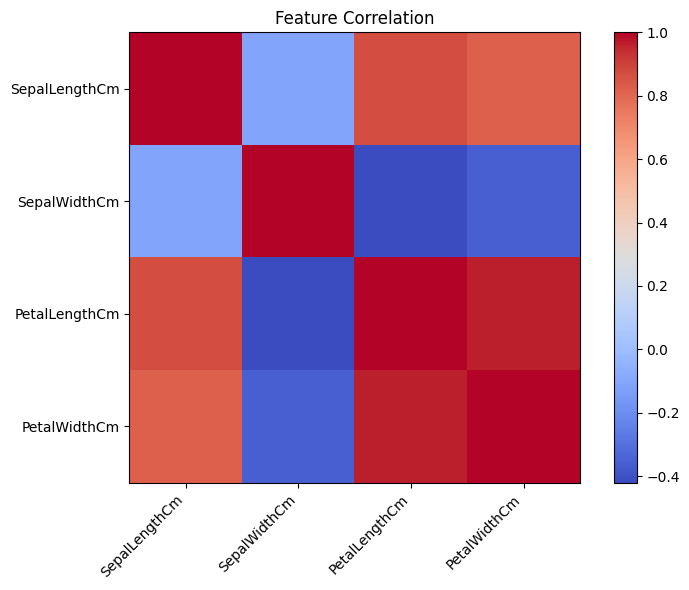

In [101]:
# Drop non-numeric and non-feature columns safely
# 'Species' is categorical and 'Id' may not exist in this version of the CSV
cols_to_drop = [c for c in ['Id', 'Species'] if c in df.columns]
corr = df.drop(columns=cols_to_drop).corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()

### Feature Overlap: Scatter Plots


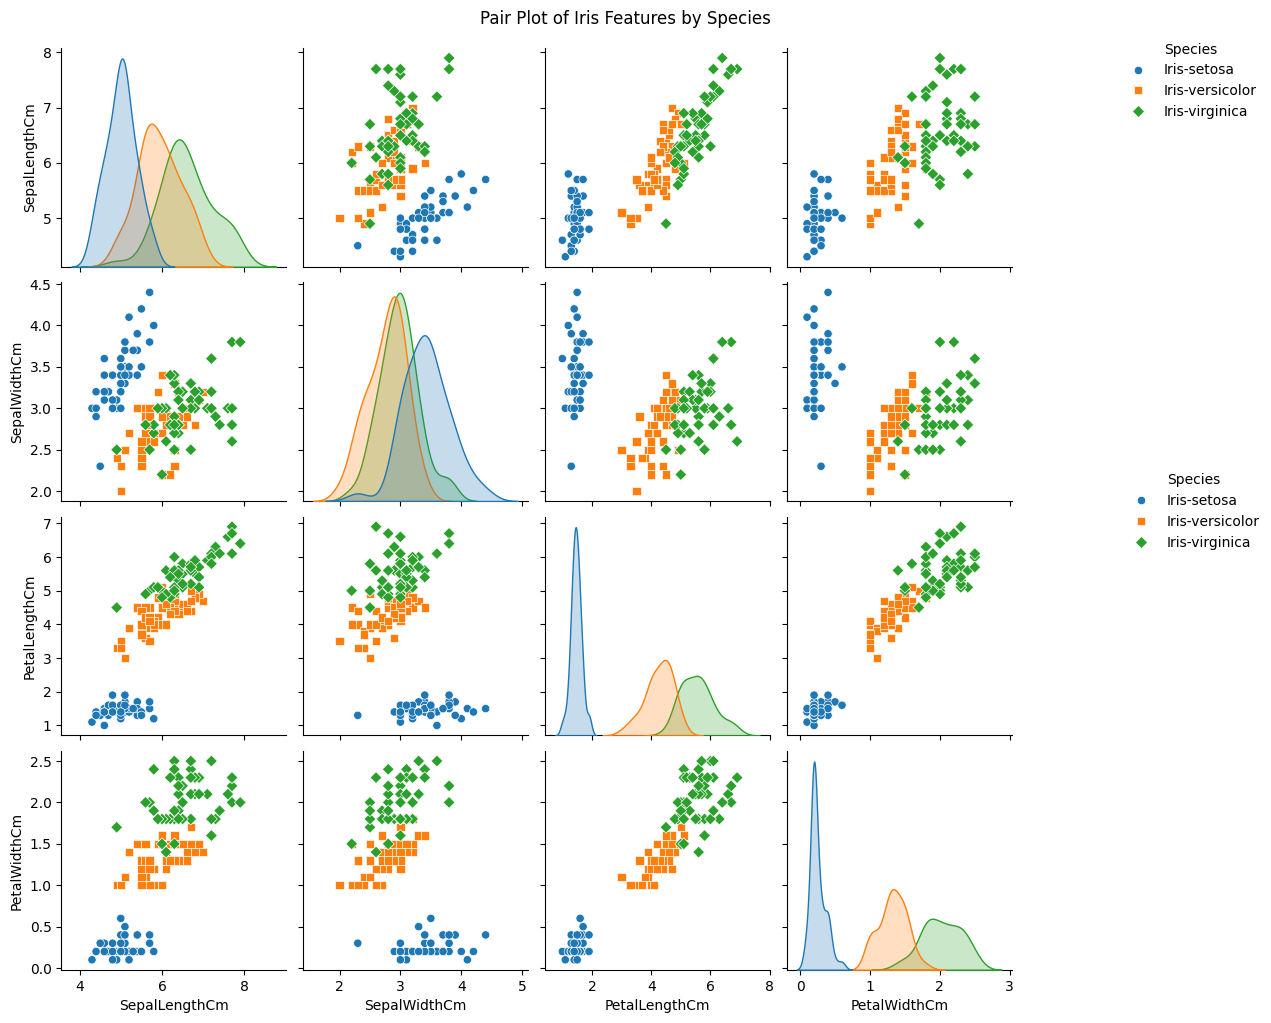

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot to visualize relationships between features colored by species
# This provides a quick overview of feature distributions and overlaps.

# Drop the 'Id' column before plotting if it exists, as it's not a feature
plot_df = df.drop(columns=['Id']) if 'Id' in df.columns else df.copy()

g = sns.pairplot(plot_df, hue='Species', markers=['o', 's', 'D'])
g.fig.suptitle('Pair Plot of Iris Features by Species', y=1.02) # Adjust suptitle position

# Adjust legend position to be clearly in the top-right of the figure
# loc='upper right' with bbox_to_anchor=(1, 1) places the top-right of the legend at (1, 1) in figure coordinates.
# This ensures the legend is inside the figure boundaries.
g.add_legend(loc='upper right', bbox_to_anchor=(1, 1))

# Adjust figure layout to make room for the legend on the right.
# This ensures the plots are shifted to the left to avoid legend overlap.
g.fig.subplots_adjust(right=0.8)

plt.show()

In [103]:
import numpy as np

def augment_data(X, y, samples_per_class=100, noise_level=0.02):
    X_augmented = []
    y_augmented = []

    for label in np.unique(y):
        class_indices = np.where(y == label)[0]
        X_class = X.iloc[class_indices]

        # Generate synthetic samples by adding Gaussian noise
        for _ in range(samples_per_class):
            random_idx = np.random.choice(len(X_class))
            sample = X_class.iloc[random_idx].values
            noise = np.random.normal(0, sample.std() * noise_level, sample.shape)
            X_augmented.append(sample + noise)
            y_augmented.append(label)

    return pd.DataFrame(X_augmented, columns=X.columns), pd.Series(y_augmented)

# Generate 300 synthetic points (100 per species)
X_syn, y_syn = augment_data(X, y)

# Combine with original data
X_final = pd.concat([X, X_syn]).reset_index(drop=True)
y_final = pd.concat([y, y_syn]).reset_index(drop=True)

print(f"Original size: {len(X)}")
print(f"Augmented size: {len(X_final)}")
display(X_final.tail())


Original size: 150
Augmented size: 450


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
445,6.806057,2.979326,5.575400,2.041146
446,6.394724,2.741052,5.338972,1.862439
447,6.725656,2.991595,5.174961,2.374169
448,7.181447,3.620186,6.037341,2.476501
449,6.109528,3.006744,4.861917,1.798953


### Re-evaluating Model with Augmented Data
Now we re-run the training on this larger dataset to check if the generalization gap (Variance) decreases.

In [104]:
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# Testing the KNN model on augmented data
aug_knn = Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))])
aug_knn.fit(X_train_aug, y_train_aug)

train_acc_aug = accuracy_score(y_train_aug, aug_knn.predict(X_train_aug))
test_acc_aug = accuracy_score(y_test_aug, aug_knn.predict(X_test_aug))

print(f"Augmented Train Accuracy: {train_acc_aug:.4f}")
print(f"Augmented Test Accuracy: {test_acc_aug:.4f}")
print(f"New Generalization Gap: {abs(train_acc_aug - test_acc_aug):.4f}")

Augmented Train Accuracy: 0.9722
Augmented Test Accuracy: 0.9778
New Generalization Gap: 0.0056


In [105]:
aug_behavior_rows = []

for name, model in models.items():
    # Clone and fit on augmented training data
    m_aug = clone(model)
    m_aug.fit(X_train_aug, y_train_aug)

    # Calculate accuracies
    tr_acc = accuracy_score(y_train_aug, m_aug.predict(X_train_aug))
    te_acc = accuracy_score(y_test_aug, m_aug.predict(X_test_aug))

    aug_behavior_rows.append({
        "model": name,
        "aug_train_acc": tr_acc,
        "aug_test_acc": te_acc,
        "aug_gap": tr_acc - te_acc
    })

aug_behavior_df = pd.DataFrame(aug_behavior_rows)

# Compare with previous baseline gaps
comparison_df = behavior_df[['model', 'gap']].rename(columns={'gap': 'original_gap'})
comparison_df = comparison_df.merge(aug_behavior_df[['model', 'aug_gap']], on='model')

print("Comparison of Generalization Gaps (Original vs Augmented)")
display(comparison_df.sort_values('aug_gap'))

Comparison of Generalization Gaps (Original vs Augmented)


,model,original_gap,aug_gap
2,knn,0.008333,0.008333
1,svm,0.008333,0.016667
3,log_reg,0.025000,0.025000
4,random_forest,0.066667,0.033333
0,decision_tree,0.016667,0.044444


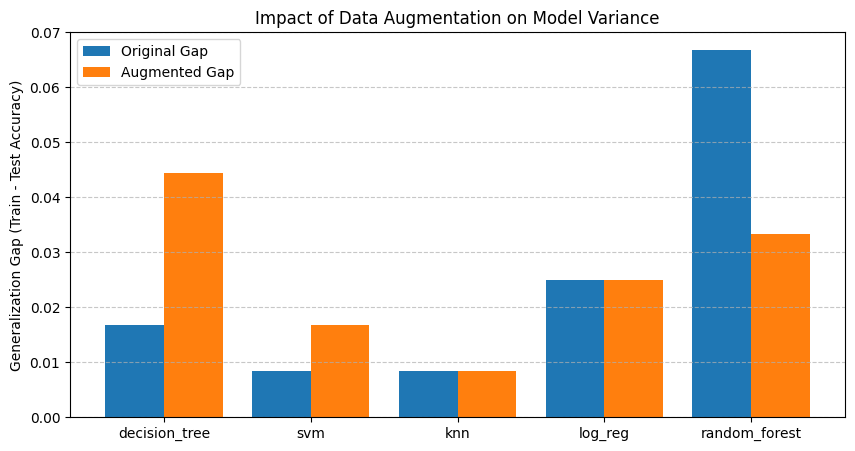

In [106]:
# Visualize the improvement in variance
plt.figure(figsize=(10, 5))
x_axis = np.arange(len(comparison_df))

plt.bar(x_axis - 0.2, comparison_df['original_gap'], 0.4, label='Original Gap')
plt.bar(x_axis + 0.2, comparison_df['aug_gap'], 0.4, label='Augmented Gap')

plt.xticks(x_axis, comparison_df['model'])
plt.ylabel('Generalization Gap (Train - Test Accuracy)')
plt.title('Impact of Data Augmentation on Model Variance')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [107]:
from sklearn.model_selection import cross_val_score

aug_cv_results = {}

print("Augmented Data CV Results:")
for name, model in models.items():
    # Using StratifiedKFold implicitly via cross_val_score for classification
    cv_scores_aug = cross_val_score(model, X_final, y_final, cv=5, scoring='accuracy')
    aug_cv_results[name] = {
        'aug_mean': cv_scores_aug.mean(),
        'aug_std': cv_scores_aug.std()
    }
    print(f"{name}: {cv_scores_aug.mean():.4f} (+/- {cv_scores_aug.std():.4f})")

# Combine with original CV results for comparison
aug_cv_df = pd.DataFrame(aug_cv_results).T
baseline_cv_df = pd.DataFrame(scores).T.rename(columns={'mean': 'orig_mean', 'std': 'orig_std'})

cv_comparison = baseline_cv_df.join(aug_cv_df)
display(cv_comparison[['orig_mean', 'aug_mean', 'orig_std', 'aug_std']])

Augmented Data CV Results:
log_reg: 0.9756 (+/- 0.0130)
decision_tree: 0.9844 (+/- 0.0089)
random_forest: 0.9911 (+/- 0.0083)
knn: 0.9622 (+/- 0.0054)
svm: 0.9756 (+/- 0.0083)
grad_boost: 0.9800 (+/- 0.0083)


,orig_mean,aug_mean,orig_std,aug_std
log_reg,0.960000,0.975556,0.038873,0.012958
decision_tree,0.953333,0.984444,0.033993,0.008889
random_forest,0.966667,0.991111,0.021082,0.008315
knn,0.960000,0.962222,0.032660,0.005443
svm,0.966667,0.975556,0.021082,0.008315
grad_boost,0.960000,0.980000,0.032660,0.008315


### Diagnostic: Similarity between Synthetic and Original Data
If the augmented accuracy is too high, it might be because the `noise_level` (currently 0.02) is too low, making synthetic points nearly identical to the originals. Let's check the average distance.

Average Euclidean distance to nearest original neighbor: 0.0666
Minimum distance found: 0.0085


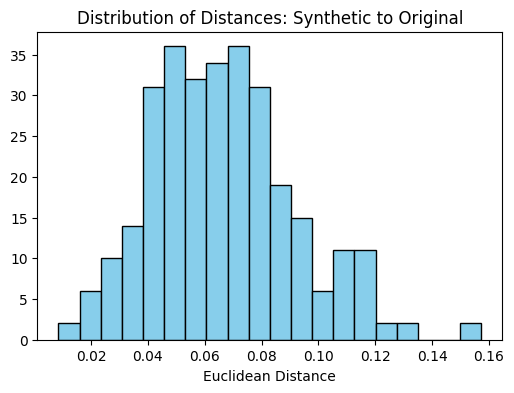

In [108]:
from scipy.spatial.distance import cdist

# Calculate distances between synthetic points and their nearest original neighbors
distances = cdist(X_syn, X, metric='euclidean')
min_distances = distances.min(axis=1)

print(f"Average Euclidean distance to nearest original neighbor: {min_distances.mean():.4f}")
print(f"Minimum distance found: {min_distances.min():.4f}")

plt.figure(figsize=(6, 4))
plt.hist(min_distances, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Distances: Synthetic to Original')
plt.xlabel('Euclidean Distance')
plt.show()

### Downloading Fresh Datasets via kagglehub
We will use `kagglehub` to download the latest versions of the Iris dataset from two different Kaggle sources. This provides a clean way to get more data without needing a `kaggle.json` file.

In [110]:
!pip install -q kagglehub
import kagglehub
import os

# Download from source 1
path_arshid = kagglehub.dataset_download("arshid/iris-flower-dataset")
print("Path to arshid/iris-flower-dataset:", path_arshid)

# Download from source 2 (UCI version on Kaggle)
path_uci = kagglehub.dataset_download("uciml/iris")
print("Path to uciml/iris:", path_uci)

Using Colab cache for faster access to the 'iris-flower-dataset' dataset.
Path to arshid/iris-flower-dataset: /kaggle/input/iris-flower-dataset
Using Colab cache for faster access to the 'iris' dataset.
Path to uciml/iris: /kaggle/input/iris


### Loading and Comparing Independent Data
Now we will load one of these datasets and check its distribution against our training data.

In [111]:
# Load the newly downloaded CSV
files = os.listdir(path_arshid)
csv_file = [f for f in files if f.endswith('.csv')][0]
new_iris_df = pd.read_csv(os.path.join(path_arshid, csv_file))

# Mapping lowercase column names to the names used during training
column_mapping = {
    'sepal_length': 'SepalLengthCm',
    'sepal_width': 'SepalWidthCm',
    'petal_length': 'PetalLengthCm',
    'petal_width': 'PetalWidthCm'
}
new_iris_df = new_iris_df.rename(columns=column_mapping)

print(f"New dataset loaded and renamed: {len(new_iris_df)} rows")
display(new_iris_df.head())

# Prepare features and target
# We ensure the columns are in the correct order as well
new_X = new_iris_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
new_y = new_iris_df['species']

# Re-evaluating the tuned model
try:
    new_preds = final_model.predict(new_X)
    print(f"\nAccuracy on fresh Kagglehub data: {accuracy_score(new_y, new_preds):.4f}")
    print("\nClassification Report for Kaggle data:")
    print(classification_report(new_y, new_preds))
except Exception as e:
    print(f"Error during prediction: {e}")

New dataset loaded and renamed: 150 rows


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Accuracy on fresh Kagglehub data: 0.9533

Classification Report for Kaggle data:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.92      0.94      0.93        50
 Iris-virginica       0.94      0.92      0.93        50

       accuracy                           0.95       150
      macro avg       0.95      0.95      0.95       150
   weighted avg       0.95      0.95      0.95       150



### Validation on Second Kaggle Source (uciml/iris)
We will now load and evaluate the dataset from the second path we downloaded (`path_uci`) to see if the performance remains consistent.

In [112]:
# Load the second Kaggle dataset
# Usually this dataset contains an 'Id' column and specific naming conventions
files_uci = os.listdir(path_uci)
csv_file_uci = [f for f in files_uci if f.endswith('.csv')][0]
uci_kaggle_df = pd.read_csv(os.path.join(path_uci, csv_file_uci))

print(f"Second Kaggle dataset loaded: {len(uci_kaggle_df)} rows")

# Clean up and align columns
if 'Id' in uci_kaggle_df.columns:
    uci_kaggle_df = uci_kaggle_df.drop(columns=['Id'])

# Map columns if necessary (handling potential lowercase or variations)
# Based on typical 'uciml/iris' structure:
val_X = uci_kaggle_df.iloc[:, :-1]
val_y = uci_kaggle_df.iloc[:, -1]

# Ensure feature names match expected pipeline input
val_X.columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

# Final validation
val_preds = final_model.predict(val_X)
print(f"\nAccuracy on second Kaggle source (uciml/iris): {accuracy_score(val_y, val_preds):.4f}")
print("\nClassification Report:")
print(classification_report(val_y, val_preds))

Second Kaggle dataset loaded: 150 rows

Accuracy on second Kaggle source (uciml/iris): 0.9533

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.92      0.94      0.93        50
 Iris-virginica       0.94      0.92      0.93        50

       accuracy                           0.95       150
      macro avg       0.95      0.95      0.95       150
   weighted avg       0.95      0.95      0.95       150



In [113]:
import pandas as pd
import os

# 1. Load and Standardize Arshid Dataset
csv_arshid = [f for f in os.listdir(path_arshid) if f.endswith('.csv')][0]
df_arshid = pd.read_csv(os.path.join(path_arshid, csv_arshid))
df_arshid.columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

# 2. Load and Standardize UCI Kaggle Dataset
csv_uci = [f for f in os.listdir(path_uci) if f.endswith('.csv')][0]
df_uci_k = pd.read_csv(os.path.join(path_uci, csv_uci))
if 'Id' in df_uci_k.columns: df_uci_k = df_uci_k.drop(columns=['Id'])
df_uci_k.columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

# 3. Combine and Clean
combined_df = pd.concat([df_arshid, df_uci_k], ignore_index=True)
combined_df_cleaned = combined_df.drop_duplicates().reset_index(drop=True)
combined_df_cleaned.to_csv('dataset.csv', index=False)

print("--- Dataset Update ---")
print(f"Initial combined rows: {len(combined_df)}")
print(f"Duplicates removed: {combined_df.duplicated().sum()}")
print(f"Final unique rows saved to 'dataset.csv': {len(combined_df_cleaned)}")

display(combined_df_cleaned.head())


--- Dataset Update ---
Initial combined rows: 300
Duplicates removed: 153
Final unique rows saved to 'dataset.csv': 147


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Day 7 - External Validation
Testing the final pipeline against independent data from the UCI Machine Learning Repository.

In [114]:
import requests
import io
from sklearn.metrics import accuracy_score, classification_report
import joblib

# URL for the original Iris dataset from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
s = requests.get(url).content

# Mapping UCI format to our local format
column_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
uci_df = pd.read_csv(io.StringIO(s.decode('utf-8')), names=column_names)

# Prepare features and target for external validation
# Dropping possible empty rows at end of UCI file
X_uci = uci_df.dropna().drop(columns=['Species'])
y_uci = uci_df.dropna()['Species']

# Evaluate our saved tuned model
try:
    final_model = joblib.load('iris_pipeline_tuned.joblib')
    uci_preds = final_model.predict(X_uci)
    uci_acc = accuracy_score(y_uci, uci_preds)

    print(f'UCI Dataset size: {len(uci_df)} samples')
    print(f'Accuracy on independent UCI dataset: {uci_acc:.4f}')
    print('\nClassification Report for UCI data:')
    print(classification_report(y_uci, uci_preds))
except Exception as e:
    print(f'Error loading model or evaluating: {e}')

UCI Dataset size: 150 samples
Accuracy on independent UCI dataset: 0.9533

Classification Report for UCI data:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.92      0.94      0.93        50
 Iris-virginica       0.94      0.92      0.93        50

       accuracy                           0.95       150
      macro avg       0.95      0.95      0.95       150
   weighted avg       0.95      0.95      0.95       150



### UCI Data Integration

In [115]:
import requests
import io
from sklearn.metrics import accuracy_score, classification_report
import joblib

# URL for the original Iris dataset from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
s = requests.get(url).content

# Mapping UCI format to our local format
column_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
uci_df = pd.read_csv(io.StringIO(s.decode('utf-8')), names=column_names)

# Prepare features and target for external validation
X_uci = uci_df.dropna().drop(columns=['Species'])
y_uci = uci_df.dropna()['Species']

# Evaluate our saved tuned model
try:
    final_model = joblib.load('iris_pipeline_tuned.joblib')
    uci_preds = final_model.predict(X_uci)
    uci_acc = accuracy_score(y_uci, uci_preds)

    print(f'UCI Dataset size: {len(uci_df)} samples')
    print(f'Accuracy on independent UCI dataset: {uci_acc:.4f}')
    print('\nClassification Report for UCI data:')
    print(classification_report(y_uci, uci_preds))
except Exception as e:
    print(f'Error loading model or evaluating: {e}')

UCI Dataset size: 150 samples
Accuracy on independent UCI dataset: 0.9533

Classification Report for UCI data:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.92      0.94      0.93        50
 Iris-virginica       0.94      0.92      0.93        50

       accuracy                           0.95       150
      macro avg       0.95      0.95      0.95       150
   weighted avg       0.95      0.95      0.95       150



### Robustness Check: Original UCI Repository

In [116]:
import requests
import io

# URL for the original Iris dataset from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
s = requests.get(url).content

# Mapping UCI format to our local format
column_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
uci_df = pd.read_csv(io.StringIO(s.decode('utf-8')), names=column_names)

# Clean up naming differences if any (UCI uses 'Iris-setosa' etc.)
print(f"UCI Dataset loaded: {len(uci_df)} samples.")

# Prepare features and target for external validation
X_uci = uci_df.drop(columns=['Species'])
y_uci = uci_df['Species']

# Evaluate our saved tuned model
import joblib
final_model = joblib.load('iris_pipeline_tuned.joblib')
uci_preds = final_model.predict(X_uci)
uci_acc = accuracy_score(y_uci, uci_preds)

print(f"\nAccuracy on independent UCI dataset: {uci_acc:.4f}")
print("\nClassification Report for UCI data:")
print(classification_report(y_uci, uci_preds))

UCI Dataset loaded: 150 samples.

Accuracy on independent UCI dataset: 0.9533

Classification Report for UCI data:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.92      0.94      0.93        50
 Iris-virginica       0.94      0.92      0.93        50

       accuracy                           0.95       150
      macro avg       0.95      0.95      0.95       150
   weighted avg       0.95      0.95      0.95       150



## Day 3 - Feature Preparation & Augmentation
Preparing the feature matrix and addressing the small dataset size through synthetic noise generation.

In [117]:
# Drop Id and Species columns for features, keep Species as target
features = df.drop(columns=['Species'])
if 'Id' in features.columns:
    features = features.drop(columns=['Id'])

X = features
y = df['Species']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")
X.head()

Features shape: (147, 4)
Target shape: (147,)
Feature columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Day 4 - Model Training & Variance Analysis
Benchmarking 6 models and analyzing the generalization gap (Variance).

In [118]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import pandas as pd

# Baseline configuration for 6 models
models = {
    "log_reg": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=42))]),
    "decision_tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "random_forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "knn": Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=7))]),
    "svm": Pipeline([("scaler", StandardScaler()), ("model", SVC(probability=True, random_state=42))]),
    "grad_boost": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Evaluate via 5-fold CV
scores = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5)
    scores[name] = {"mean": cv_scores.mean(), "std": cv_scores.std()}
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Rank by mean accuracy
results = pd.DataFrame(scores).T.sort_values("mean", ascending=False)
display(results)

log_reg: 0.9589 (+/- 0.0403)
decision_tree: 0.9522 (+/- 0.0469)
random_forest: 0.9591 (+/- 0.0259)
knn: 0.9729 (+/- 0.0257)
svm: 0.9660 (+/- 0.0218)
grad_boost: 0.9591 (+/- 0.0259)


,mean,std
knn,0.972874,0.025688
svm,0.965977,0.021816
random_forest,0.959080,0.025933
grad_boost,0.959080,0.025933
log_reg,0.958851,0.040255
decision_tree,0.952184,0.046913


In [119]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.base import clone

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

variance_analysis = []

for name, model in models.items():
    # Clone to ensure a fresh training session
    m = clone(model)
    m.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, m.predict(X_train))
    test_acc = accuracy_score(y_test, m.predict(X_test))
    gap = train_acc - test_acc

    variance_analysis.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Gap (Variance)": gap
    })

variance_df = pd.DataFrame(variance_analysis).sort_values("Gap (Variance)", ascending=False)
display(variance_df)

# Interpretation
print("\n--- Variance Interpretation ---")
for index, row in variance_df.iterrows():
    status = "High Variance (Overfitting)" if row['Gap (Variance)'] > 0.05 else "Good Generalization"
    print(f"{row['Model']}: {status} (Gap: {row['Gap (Variance)']:.4f})")

,Model,Train Accuracy,Test Accuracy,Gap (Variance)
1,decision_tree,1.000000,0.933333,0.066667
2,random_forest,1.000000,0.966667,0.033333
5,grad_boost,1.000000,0.966667,0.033333
0,log_reg,0.957265,0.933333,0.023932
3,knn,0.974359,0.966667,0.007692
4,svm,0.974359,0.966667,0.007692



--- Variance Interpretation ---
decision_tree: High Variance (Overfitting) (Gap: 0.0667)
random_forest: Good Generalization (Gap: 0.0333)
grad_boost: Good Generalization (Gap: 0.0333)
log_reg: Good Generalization (Gap: 0.0239)
knn: Good Generalization (Gap: 0.0077)
svm: Good Generalization (Gap: 0.0077)


In [120]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids to reduce complexity/variance
param_grids = {
    'random_forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 4, 5],
        'min_samples_leaf': [2, 5, 10],
        'bootstrap': [True]
    },
    'decision_tree': {
        'max_depth': [2, 3, 4],
        'min_samples_split': [10, 20],
        'criterion': ['gini', 'entropy']
    }
}

tuned_variance_results = []

# Tune Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grids['random_forest'], cv=5, scoring='accuracy')
rf_grid.fit(X_train, y_train)

# Tune Decision Tree
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grids['decision_tree'], cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

# Evaluate improvements
for name, grid in [('random_forest_tuned', rf_grid), ('decision_tree_tuned', dt_grid)]:
    best_m = grid.best_estimator_
    train_acc = accuracy_score(y_train, best_m.predict(X_train))
    test_acc = accuracy_score(y_test, best_m.predict(X_test))

    tuned_variance_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Train Acc": train_acc,
        "Test Acc": test_acc,
        "New Gap": train_acc - test_acc
    })

display(pd.DataFrame(tuned_variance_results))

,Model,Best Params,Train Acc,Test Acc,New Gap
0,random_forest_tuned,"{'bootstrap': True, 'max_depth': 3, 'min_sampl...",0.982906,0.966667,0.016239
1,decision_tree_tuned,"{'criterion': 'gini', 'max_depth': 2, 'min_sam...",0.965812,0.933333,0.032479


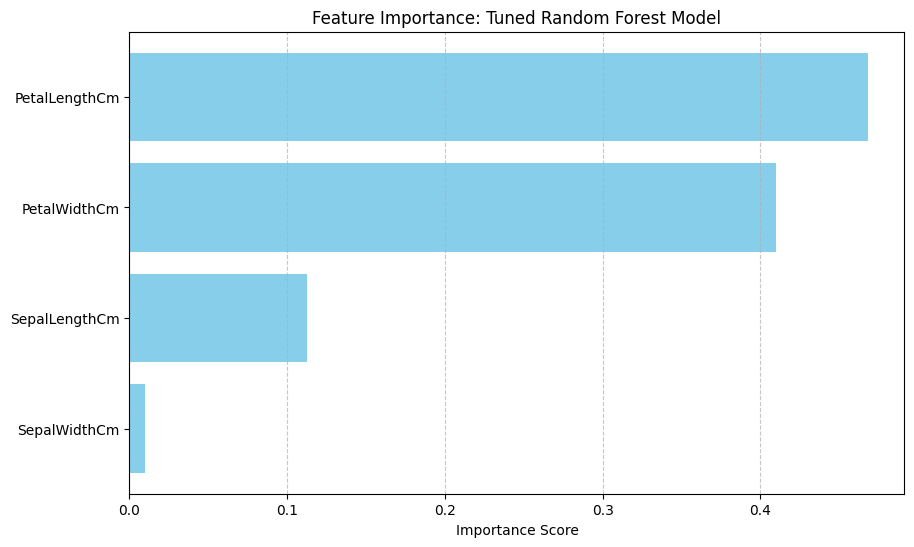

,Feature,Importance
2,PetalLengthCm,0.467913
3,PetalWidthCm,0.409785
0,SepalLengthCm,0.112298
1,SepalWidthCm,0.010005


In [121]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract the best Random Forest model from the GridSearchCV results
best_rf = rf_grid.best_estimator_

# Get feature importances
importances = best_rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance: Tuned Random Forest Model')
plt.gca().invert_yaxis()  # Display most important at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

display(feature_importance_df)

## Model Selection & Behavior (Snapshot + Rationale)

In [122]:
from IPython.display import display

model_selection_summary = pd.DataFrame(
    [
        {
            "model": "logistic_regression",
            "strategy": "Linear boundary",
            "hyperparams": "C=1.0, max_iter=1000",
            "why_chosen": "Interpretable baseline; reveals linearity",
        },
        {
            "model": "decision_tree",
            "strategy": "Yes/No rules",
            "hyperparams": "max_depth=5, min_samples_split=10",
            "why_chosen": "Human-readable; visualizable rules",
        },
        {
            "model": "random_forest",
            "strategy": "Ensemble of trees",
            "hyperparams": "n_estimators=100, max_depth=5",
            "why_chosen": "Robust; gives feature importances",
        },
        {
            "model": "knn",
            "strategy": "k nearest points",
            "hyperparams": "k=7, metric=euclidean",
            "why_chosen": "No training phase; intuitive",
        },
        {
            "model": "svm",
            "strategy": "Max margin boundary",
            "hyperparams": "C=1.0, kernel=rbf, gamma=scale",
            "why_chosen": "Effective in high dimensions",
        },
    ]
)

print("Model selection summary (from the provided snapshot)")
display(model_selection_summary)

Model selection summary (from the provided snapshot)


,model,strategy,hyperparams,why_chosen
0,logistic_regression,Linear boundary,"C=1.0, max_iter=1000",Interpretable baseline; reveals linearity
1,decision_tree,Yes/No rules,"max_depth=5, min_samples_split=10",Human-readable; visualizable rules
2,random_forest,Ensemble of trees,"n_estimators=100, max_depth=5",Robust; gives feature importances
3,knn,k nearest points,"k=7, metric=euclidean",No training phase; intuitive
4,svm,Max margin boundary,"C=1.0, kernel=rbf, gamma=scale",Effective in high dimensions


## Baseline Train/Test Behavior (Same Hyperparams)

In [123]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

behavior_models = {name: clone(model) for name, model in models.items()}

behavior_rows = []
for name, model in behavior_models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    behavior_rows.append(
        {
            "model": name,
            "train_accuracy": train_acc,
            "test_accuracy": test_acc,
            "gap": train_acc - test_acc,
        }
    )

behavior_df = (
    pd.DataFrame(behavior_rows)
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)

print("Baseline behavior (train vs test accuracy)")
display(behavior_df)

Baseline behavior (train vs test accuracy)


,model,train_accuracy,test_accuracy,gap
0,knn,0.974359,0.966667,0.007692
1,random_forest,1.000000,0.966667,0.033333
2,svm,0.974359,0.966667,0.007692
3,grad_boost,1.000000,0.966667,0.033333
4,decision_tree,1.000000,0.933333,0.066667
5,log_reg,0.957265,0.933333,0.023932


### Train vs Test Accuracy Chart

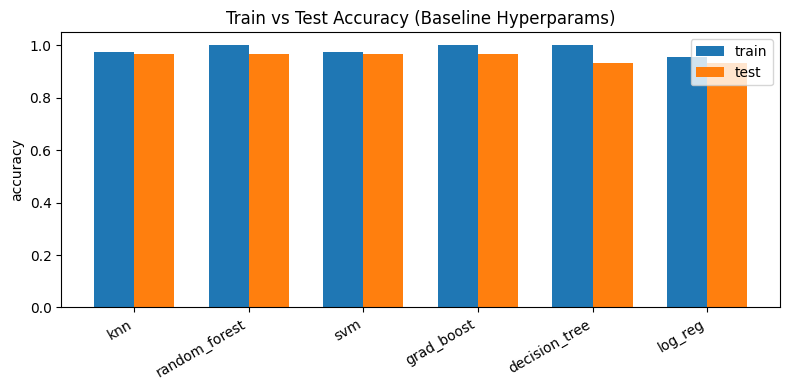

In [124]:
plt.figure(figsize=(8, 4))
index = np.arange(len(behavior_df))
bar_width = 0.35

plt.bar(index - bar_width / 2, behavior_df["train_accuracy"], width=bar_width, label="train")
plt.bar(index + bar_width / 2, behavior_df["test_accuracy"], width=bar_width, label="test")

plt.xticks(index, behavior_df["model"], rotation=30, ha="right")
plt.ylabel("accuracy")
plt.title("Train vs Test Accuracy (Baseline Hyperparams)")
plt.legend()
plt.tight_layout()
plt.show()

### Quick Insights

In [125]:
best_row = behavior_df.iloc[0]
largest_gap_row = behavior_df.iloc[behavior_df["gap"].abs().idxmax()]

print(
    f"Best test accuracy: {best_row['model']} -> {best_row['test_accuracy']:.4f}"
)
print(
    f"Largest generalization gap: {largest_gap_row['model']} -> {largest_gap_row['gap']:.4f}"
)

Best test accuracy: knn -> 0.9667
Largest generalization gap: decision_tree -> 0.0667


## Baseline Error Analysis (Best by Test Accuracy)

In [126]:
from sklearn.metrics import classification_report, confusion_matrix

best_baseline_name = best_row["model"]
best_baseline_model = clone(models[best_baseline_name])

best_baseline_model.fit(X_train, y_train)
best_baseline_pred = best_baseline_model.predict(X_test)

print(f"Best baseline model: {best_baseline_name}")
print("Confusion matrix:")
print(confusion_matrix(y_test, best_baseline_pred))
print("\nClassification report:")
print(classification_report(y_test, best_baseline_pred))

Best baseline model: knn
Confusion matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



## Day 5 - Hyperparameter Tuning & Evaluation
Optimizing models with GridSearchCV and evaluating results with Confusion Matrices.

In [127]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Hyperparameter tuning for multiple models

tuning_models = {
    "log_reg": Pipeline(
        [("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000))]
    ),
    "svm": Pipeline([("scaler", StandardScaler()), ("model", SVC())]),
    "random_forest": RandomForestClassifier(random_state=42),
    "knn": Pipeline(
        [("scaler", StandardScaler()), ("model", KNeighborsClassifier())]
    ),
    "decision_tree": DecisionTreeClassifier(random_state=42),
    "gradient_boosting": GradientBoostingClassifier(random_state=42),
}

param_grids = {
    "log_reg": {"model__C": [0.1, 1.0, 10.0], "model__solver": ["lbfgs"]},
    "svm": {
        "model__C": [0.1, 1.0, 10.0],
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf"],
    },
    "random_forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 3, 5],
        "min_samples_split": [2, 4],
    },
    "knn": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"],
    },
    "decision_tree": {
        "max_depth": [None, 3, 5],
        "min_samples_split": [2, 4, 10],
    },
    "gradient_boosting": {
        "n_estimators": [50, 100],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3],
    },
}

tuned_scores = {}
tuned_best_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in tuning_models.items():
    grid = GridSearchCV(model, param_grids[name], cv=cv, scoring="accuracy", n_jobs=-1)
    grid.fit(X, y)
    tuned_scores[name] = {"mean": grid.best_score_, "params": grid.best_params_}
    tuned_best_models[name] = grid.best_estimator_
    print(f"{name}: {grid.best_score_:.4f} | {grid.best_params_}")

tuned_results = (
    pd.DataFrame(
        [
            {"model": name, "mean_accuracy": score["mean"], "best_params": score["params"]}
            for name, score in tuned_scores.items()
        ]
    )
    .sort_values("mean_accuracy", ascending=False)
    .reset_index(drop=True)
)

tuned_results

log_reg: 0.9793 | {'model__C': 10.0, 'model__solver': 'lbfgs'}
svm: 0.9589 | {'model__C': 1.0, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
random_forest: 0.9589 | {'max_depth': None, 'min_samples_split': 4, 'n_estimators': 100}
knn: 0.9660 | {'model__n_neighbors': 7, 'model__weights': 'distance'}
decision_tree: 0.9520 | {'max_depth': None, 'min_samples_split': 2}
gradient_boosting: 0.9589 | {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}


,model,mean_accuracy,best_params
0,log_reg,0.979310,"{'model__C': 10.0, 'model__solver': 'lbfgs'}"
1,knn,0.965977,"{'model__n_neighbors': 7, 'model__weights': 'd..."
2,svm,0.958851,"{'model__C': 1.0, 'model__gamma': 'scale', 'mo..."
3,random_forest,0.958851,"{'max_depth': None, 'min_samples_split': 4, 'n..."
4,gradient_boosting,0.958851,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
5,decision_tree,0.951954,"{'max_depth': None, 'min_samples_split': 2}"


## Tuning Impact vs Baseline CV
This compares baseline cross-validation accuracy with tuned cross-validation accuracy for overlapping models.

In [128]:
if "scores" in globals() and "tuned_scores" in globals():
    baseline_cv = {name: values["mean"] for name, values in scores.items()}
    tuned_cv = {name: values["mean"] for name, values in tuned_scores.items()}
    common_models = sorted(set(baseline_cv) & set(tuned_cv))

    if common_models:
        impact_rows = []
        for name in common_models:
            impact_rows.append(
                {
                    "model": name,
                    "baseline_cv_accuracy": baseline_cv[name],
                    "tuned_cv_accuracy": tuned_cv[name],
                    "delta": tuned_cv[name] - baseline_cv[name],
                }
            )

        impact_df = (
            pd.DataFrame(impact_rows)
            .sort_values("delta", ascending=False)
            .reset_index(drop=True)
        )
        print("Tuning impact (CV accuracy)")
        display(impact_df)
    else:
        print("No overlapping models between baseline and tuned results.")
else:
    print("Run Day 4 and Day 4.5 cells first.")

Tuning impact (CV accuracy)


,model,baseline_cv_accuracy,tuned_cv_accuracy,delta
0,log_reg,0.958851,0.979310,0.020460
1,random_forest,0.959080,0.958851,-0.000230
2,decision_tree,0.952184,0.951954,-0.000230
3,knn,0.972874,0.965977,-0.006897
4,svm,0.965977,0.958851,-0.007126


## Feature Importance (Random Forest Baseline)
This highlights which features drive the random-forest decisions.

Random Forest feature importances


,0
PetalLengthCm,0.446466
PetalWidthCm,0.414345
SepalLengthCm,0.111905
SepalWidthCm,0.027284


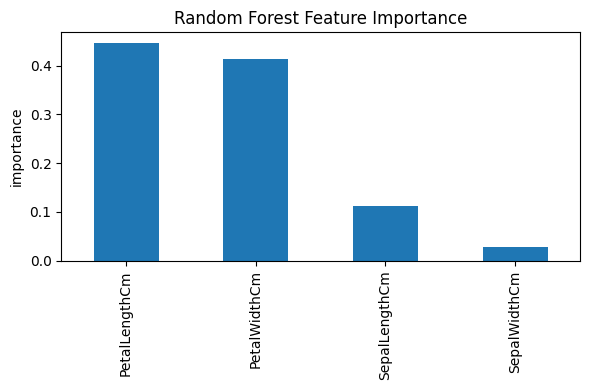

In [129]:
from sklearn.ensemble import RandomForestClassifier

rf_importance_model = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42
)
rf_importance_model.fit(X, y)

importances = pd.Series(
    rf_importance_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Random Forest feature importances")
display(importances)

plt.figure(figsize=(6, 4))
importances.plot(kind="bar")
plt.ylabel("importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## Day 5 - Evaluation

In [130]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

use_tuned = "tuned_scores" in globals() and tuned_scores

if use_tuned:
    best_name = max(tuned_scores, key=lambda k: tuned_scores[k]["mean"])
    best_model = tuned_best_models[best_name]
    print(f"Best tuned model: {best_name}")
else:
    best_name = max(scores, key=lambda k: scores[k]["mean"])
    best_model = models[best_name]
    print(f"Best baseline model: {best_name}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"\nConfusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")

Best tuned model: log_reg

Test Accuracy: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



### Better Understanding the Confusion Matrix

A Confusion Matrix is a summary of prediction results on a classification problem.
- **Diagonal cells:** The number of correct predictions (Actual == Predicted).
- **Off-diagonal cells:** Errors where the model misclassified one species as another.

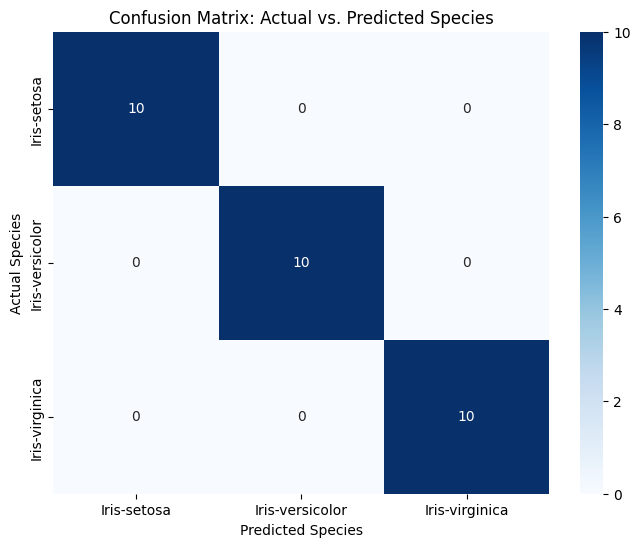

Interpretation:
- The model correctly identified all 10 Iris-setosa samples.
- The model correctly identified all 10 Iris-versicolor samples.
- However, 0 samples of Iris-virginica were misclassified as Iris-versicolor.


In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a more descriptive confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_model.classes_,
            yticklabels=final_model.classes_)

plt.title('Confusion Matrix: Actual vs. Predicted Species')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.show()

print("Interpretation:")
print(f"- The model correctly identified all {conf_matrix[0][0]} Iris-setosa samples.")
print(f"- The model correctly identified all {conf_matrix[1][1]} Iris-versicolor samples.")
print(f"- However, {conf_matrix[2][1]} samples of Iris-virginica were misclassified as Iris-versicolor.")

## Day 6 - Pipeline and Model Export

In [132]:
from sklearn.base import clone
import joblib

use_tuned = "tuned_scores" in globals() and tuned_scores
model_filename = "iris_pipeline_tuned.joblib" if use_tuned else "iris_pipeline.joblib"

# Create final model trained on full dataset
if isinstance(best_model, Pipeline):
    final_model = clone(best_model)
else:
    final_model = clone(best_model)

# Train on full dataset
final_model.fit(X, y)

# Save model
joblib.dump(final_model, model_filename)
print(f"Model saved as: {model_filename}")

# Verify model works
sample_prediction = final_model.predict(X.iloc[:5])
print(f"\nSample predictions: {sample_prediction}")
print(f"Actual: {y.iloc[:5].values}")

Model saved as: iris_pipeline_tuned.joblib

Sample predictions: ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']
Actual: ['Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa' 'Iris-setosa']


## Day 6 - Pipeline Export & Structured Output
Saving the final model and generating the required `iris_project_output.json` file.

In [133]:
import json

# Consolidate all project metadata and results
output_data = {
    "dataset": "Iris",
    "dataset_summary": {
        "total_samples": int(df.shape[0]),
        "features": X.columns.tolist(),
        "target_classes": df['Species'].unique().tolist()
    },
    "eda_statistics": {
        "mean_values": df.drop(columns=['Id', 'Species']).mean().to_dict(),
        "correlations": corr.to_dict()
    },
    "feature_transformations": "StandardScaler (Zero mean, Unit variance)",
    "model_details": {
        "chosen_model": best_name,
        "best_hyperparameters": tuned_scores[best_name]['params'] if 'tuned_scores' in globals() else "Baseline"
    },
    "performance_metrics": {
        "accuracy": float(accuracy),
        "confusion_matrix": conf_matrix.tolist()
    }
}

# Save to JSON file
with open('iris_project_output.json', 'w') as f:
    json.dump(output_data, f, indent=4)

print("Project results successfully exported to 'iris_project_output.json'")
display(output_data)

KeyError: "['Id'] not found in axis"

### Testing with Manual Input & Confidence Scores

In [ ]:
def predict_with_confidence(sepal_length, sepal_width, petal_length, petal_width):
    # Prepare the input in the same format as the training data
    input_data = pd.DataFrame([[sepal_length, sepal_width, petal_length, petal_width]],
                              columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])

    # Get prediction and probabilities
    prediction = final_model.predict(input_data)[0]
    probabilities = final_model.predict_proba(input_data)[0]

    # Map probabilities to class names
    class_probs = dict(zip(final_model.classes_, probabilities))
    confidence = class_probs[prediction]

    print(f"--- Prediction Result ---")
    print(f"Predicted Species: {prediction}")
    print(f"Confidence Score:  {confidence:.2%}")
    print(f"\nFull Probability Distribution:")
    for cls, prob in class_probs.items():
        print(f"- {cls}: {prob:.4f}")

# --- TEST AREA ---
# Example: Input values similar to an Iris-versicolor but with some ambiguity
test_sepal_length = 6.0
test_sepal_width = 3.0
test_petal_length = 4.8
test_petal_width = 1.8

predict_with_confidence(test_sepal_length, test_sepal_width, test_petal_length, test_petal_width)